In [1]:
# Cell 1 — Config & Imports
# - 指定向量文件路径（你的 5 波段 npz）
# - 设置聚类数量、潜空间维度、训练轮数等

import os, json, math, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from scipy.optimize import linear_sum_assignment as hungarian

# 可选：UMAP；若缺失则退回TSNE
use_umap = True
try:
    from umap import UMAP
except Exception:
    use_umap = False
    from sklearn.manifold import TSNE

# ======== 路径与参数（按需修改）========
npz_path     = r"E:\NUS\galaxy\rc3\vectors_rotinv_all2.npz"  # ← 你的5波段向量文件
output_dir   = r"E:\NUS\galaxy\ae_unsup_out"
Path(output_dir).mkdir(parents=True, exist_ok=True)

global_rand_seed = 1538847
random.seed(global_rand_seed); np.random.seed(global_rand_seed); torch.manual_seed(global_rand_seed)

# AE & 训练
# latent_dim    = 64          # 潜空间维度：40/64/100 均可；64较通用
# batch_size    = 128
# num_epochs    = 80
learning_rate = 1e-3
patience_es   = 8           # 早停
latent_dim = 16       # ← 原来可能是 40/64/100，收紧到 16
batch_size  = 32
num_epochs  = 60



# 聚类
n_clusters    = 10         # 初始聚类数，后续可根据可视化/纯度调整

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [2]:
# Cell 2 — 读取 5 波段向量并构建特征矩阵 X
# - 自动识别 npz 内的 key 结构（常见两种：逐波段二维数组 / 已拼接二维数组）
# - 支持可选的“波段权重”后拼接
data = np.load(npz_path, allow_pickle=True)
print("NPZ keys:", list(data.keys()))
# 尝试猜测结构：
# 1) 可能是每个波段各自的矩阵，如: g_XA, g_XB, r_XA, r_XB, ... 或 bands: ['u','g','r','i','z']
# 2) 也可能已经拼好了 X: (N, D_total)
# 3) 可能含文件名/ID: 'files', 'names', 'ids' 等

# 把所有形如 (N, D) 的数组收集起来（排除明显不是样本×特征的，如标量或1D）
mat_list = []
meta = {}
N_common = None
for k in data.files:
    arr = data[k]
    if isinstance(arr, np.ndarray) and arr.ndim == 2:
        if N_common is None: N_common = arr.shape[0]
        if arr.shape[0] == N_common:
            mat_list.append((k, arr))
    elif isinstance(arr, np.ndarray) and arr.ndim == 1:
        meta[k] = arr

print(f"Detected {len(mat_list)} candidate feature blocks with N={N_common}.")
for k, a in mat_list[:8]:
    print(k, a.shape)

# 如果文件里已经有“总特征矩阵”X，就直接用；否则把多个块按列拼接
X = None
cand_total_names = [k for k,_ in mat_list if k.lower() in ["x", "features", "xb", "xa_xb", "feat"]]
if len(cand_total_names) == 1:
    X = data[cand_total_names[0]]
else:
    # 最稳妥：把所有 (N, D) block 逐列拼起来（常见做法：将每个波段的 XA|XB 拼接）
    # 你也可以在这里自定义：只选某些key，或给某些波段加权
    # 示例：若key名里带有波段字母（u,g,r,i,z），可以排序后拼接
    # 这里简单按 key 名字母顺序拼接
    mat_list_sorted = sorted(mat_list, key=lambda kv: kv[0])
    X = np.concatenate([a for _, a in mat_list_sorted], axis=1)

print("Final X shape:", X.shape)

# 附带文件名/ID（若存在）
if "files" in data:
    files = data["files"]
elif "names" in data:
    files = data["names"]
elif "ids" in data:
    files = data["ids"]
else:
    files = np.array([f"obj_{i:05d}" for i in range(X.shape[0])])
print("files shape:", files.shape, "| example:", files[:3])


NPZ keys: ['XA', 'XB', 'names', 'meta']
Detected 2 candidate feature blocks with N=478.
XA (478, 4096)
XB (478, 268)
Final X shape: (478, 268)
files shape: (478,) | example: ['g\\CGCG_477-_39_37_g.fits' 'g\\CGCG_477-_44_65_g.fits'
 'g\\CGCG_477-_49_101_g.fits']


In [3]:
# === Cell 2A — 多波段合并为“每星系一条样本”：基于 XB 聚合 ===
import re
from pathlib import Path
import numpy as np

# 需要：data 已加载；包含 keys: XA (480,4096), XB (480,256), names (480,)
XA = data["XA"]
XB = data["XB"]
names = data["names"].astype(str)

band_order = ["r", "g", "i", "z", "u"]   # 固定顺序（你也可以改成 ["u","g","r","i","z"]）
D = XB.shape[1]                          # 256

def parse_band_and_id(s: str):
    """从 names 中提取 band 和 galaxy_id，尽量鲁棒。
       支持模式：'g\\CGCG_..._g.fits'，或 '..._r.fits'，或目录前缀 'r\\...'
    """
    s2 = s.replace("\\", "/").lower()
    base = Path(s2).name  # e.g., 'cgcg_477-_39_37_g.fits' 或 'g.fits'等
    # 1) 优先从文件名末尾的 _{band}.fits 识别
    m = re.search(r"_([ugriz])\.fits$", base)
    band = m.group(1) if m else None
    # 2) 若末尾没写 band，就尝试从路径前缀获取
    if band is None:
        m2 = re.match(r"([ugriz])\/", s2)
        band = m2.group(1) if m2 else None
    # 3) 构造 galaxy_id：去掉末尾的 _{band}.fits，再去掉前缀 band/
    galaxy_id = base
    if band:
        galaxy_id = re.sub(rf"_{band}\.fits$", "", galaxy_id)  # 去掉末尾波段
    # 去掉可能的前缀 'g\' 这类
    galaxy_id = galaxy_id.lstrip("ugriz_/\\")
    return band, galaxy_id

# 按星系聚合：每个 galaxy_id -> {band: row_index}
gal2bandidx = {}
for idx, nm in enumerate(names):
    band, gid = parse_band_and_id(nm)
    if gid is None or band is None:
        # 跳过无法解析的记录
        continue
    gal2bandidx.setdefault(gid, {})[band] = idx

# 构造 galaxy 级别的特征矩阵：按 band_order 依次拼接 XB；缺失用 0；并附加一个 5维mask
X_blocks = []
mask_blocks = []
galaxy_ids = []
rep_file = []

def pick_rep(idx_map):
    """从这个星系的现有波段中，挑一个代表文件（优先 r>g>i>z>u）"""
    for b in band_order:
        if b in idx_map:
            return names[idx_map[b]]
    # 如果一个都没有（理论不该发生），退回任意
    k = next(iter(idx_map.values()))
    return names[k]

for gid, idx_map in gal2bandidx.items():
    feats = []
    masks = []
    for b in band_order:
        if b in idx_map:
            feats.append(XB[idx_map[b]])         # (256,)
            masks.append(1.0)
        else:
            feats.append(np.zeros(D, dtype=np.float32))
            masks.append(0.0)
    X_blocks.append(np.concatenate(feats, axis=0))  # (256*B,)
    mask_blocks.append(np.array(masks, dtype=np.float32))  # (B,)
    galaxy_ids.append(gid)
    rep_file.append(pick_rep(idx_map))

X_gal = np.concatenate([np.stack(X_blocks, 0), np.stack(mask_blocks, 0)], axis=1)
files_gal = np.array(rep_file)
galaxy_ids = np.array(galaxy_ids)

print("Galaxy-level X shape:", X_gal.shape, "(= 256*B + B)", "B =", len(band_order))
print("Num galaxies:", len(galaxy_ids))
print("Example galaxy_id:", galaxy_ids[0], "| rep file:", files_gal[0])

# 后续流程用 X := X_gal, files := files_gal
X = X_gal
files = files_gal


Galaxy-level X shape: (96, 1345) (= 256*B + B) B = 5
Num galaxies: 96
Example galaxy_id: cgcg_477-_39_37 | rep file: r\CGCG_477-_39_37_r.fits


In [4]:
# Cell 3 — 预处理：缺失处理 + 标准化
# - 旋转不变特征不同维度量纲可能差异很大，统一标准化到零均值单位方差
# NaN/Inf 清理
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print("X_std:", X_std.shape, X_std.dtype)

# 保存 scalers 以便复现/上线
import joblib
joblib.dump(scaler, os.path.join(output_dir, "scaler.joblib"))


X_std: (96, 1345) float32


['E:\\NUS\\galaxy\\ae_unsup_out\\scaler.joblib']

In [5]:
# Cell 4 — 定义“向量自编码器” (MLP-AE)
# - 输入为一维向量（拼接5波段特征），多层全连接 + 非线性
# - 潜空间为 latent_dim 维
input_dim = X_std.shape[1]

class VectorAE(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(True),
            nn.Linear(1024, 256),       nn.ReLU(True),
            nn.Linear(256, latent_dim),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(True),
            nn.Linear(256, 1024),       nn.ReLU(True),
            nn.Linear(1024, input_dim),
        )
    def encode(self, x):  return self.enc(x)
    def decode(self, z):  return self.dec(z)
    def forward(self, x):
        z = self.encode(x)
        xhat = self.decode(z)
        return xhat, z

model = VectorAE(input_dim, latent_dim).to(device)
sum_params = sum(p.numel() for p in model.parameters())/1e6
print(f"Model params: {sum_params:.2f}M")


Model params: 3.29M


In [6]:
print("X_std shape:", X_std.shape)     # 应该是 (N_gal, 256*B + B)
print("files len:", len(files))        # 应该等于 N_gal
print("unique galaxy ids:", len(np.unique(galaxy_ids)))


X_std shape: (96, 1345)
files len: 96
unique galaxy ids: 96


In [7]:
# Cell 5 — 训练 AE（MSE重建 + 早停）
dataset = TensorDataset(torch.from_numpy(X_std.astype(np.float32)))
loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

best_loss = float("inf"); best_state = None; no_improve = 0

for epoch in range(1, num_epochs+1):
    model.train()
    running, n = 0.0, 0
    for (xb,) in loader:
        xb = xb.to(device)
        xhat, z = model(xb)
        loss = criterion(xhat, xb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()*xb.size(0)
        n += xb.size(0)
    ep = running / max(n,1)

    if ep < best_loss - 1e-6:
        best_loss = ep
        best_state = {k: v.detach().cpu() for k,v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    print(f"[{epoch:03d}] recon_MSE={ep:.6f}  best={best_loss:.6f}  no_improve={no_improve}")
    if no_improve >= patience_es:
        print("Early stopping.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
torch.save(model.state_dict(), os.path.join(output_dir, "vector_ae_best.pth"))
print("Saved best model.")


[001] recon_MSE=0.890817  best=0.890817  no_improve=0
[002] recon_MSE=0.799633  best=0.799633  no_improve=0
[003] recon_MSE=0.627022  best=0.627022  no_improve=0
[004] recon_MSE=0.560557  best=0.560557  no_improve=0
[005] recon_MSE=0.505873  best=0.505873  no_improve=0
[006] recon_MSE=0.462288  best=0.462288  no_improve=0
[007] recon_MSE=0.411099  best=0.411099  no_improve=0
[008] recon_MSE=0.371896  best=0.371896  no_improve=0
[009] recon_MSE=0.334216  best=0.334216  no_improve=0
[010] recon_MSE=0.303795  best=0.303795  no_improve=0
[011] recon_MSE=0.282294  best=0.282294  no_improve=0
[012] recon_MSE=0.262715  best=0.262715  no_improve=0
[013] recon_MSE=0.241353  best=0.241353  no_improve=0
[014] recon_MSE=0.225040  best=0.225040  no_improve=0
[015] recon_MSE=0.210695  best=0.210695  no_improve=0
[016] recon_MSE=0.197121  best=0.197121  no_improve=0
[017] recon_MSE=0.183795  best=0.183795  no_improve=0
[018] recon_MSE=0.170797  best=0.170797  no_improve=0
[019] recon_MSE=0.159617  be

In [8]:
# Cell 6 — 导出潜空间 Z
model.eval()
with torch.no_grad():
    Z = []
    bs = 4096
    X_tensor = torch.from_numpy(X_std.astype(np.float32)).to(device)
    for i in range(0, X_tensor.size(0), bs):
        xb = X_tensor[i:i+bs]
        z = model.encode(xb)
        Z.append(z.detach().cpu().numpy())
Z = np.concatenate(Z, axis=0)
print("Z shape:", Z.shape)

np.save(os.path.join(output_dir, "latent.npy"), Z)
np.save(os.path.join(output_dir, "files.npy"), files)


Z shape: (96, 16)


In [9]:
# === Cell K1 — Auto-K: 在 Z 上扫描 K 并选择较优 K* ===
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

X_lat = Z  # 潜空间

Ks = list(range(4, 21))   # 你也可以改成 5~15
sil, ch, db = [], [], []
labels_by_k = {}
models_by_k = {}

for k in Ks:
    km_ = KMeans(n_clusters=k, n_init=20, random_state=1538847)
    lab_ = km_.fit_predict(X_lat)
    models_by_k[k] = km_
    labels_by_k[k] = lab_
    if len(set(lab_))>1:
        sil.append(silhouette_score(X_lat, lab_))
        ch.append(calinski_harabasz_score(X_lat, lab_))
        db.append(davies_bouldin_score(X_lat, lab_))
    else:
        sil.append(-1); ch.append(0); db.append(np.inf)

# 简单综合评分（轮廓↑、CH↑、DB↓）
s_sil = (np.array(sil)-np.min(sil))/(np.ptp(sil)+1e-9)
s_ch  = (np.array(ch) -np.min(ch ))/(np.ptp(ch )+1e-9)
s_db  = 1.0 - (np.array(db)-np.min(db))/(np.ptp(db)+1e-9)
score = 0.5*s_sil + 0.4*s_ch + 0.1*s_db

k_star = Ks[int(np.argmax(score))]
km = models_by_k[k_star]      # 供后续直接使用
lab_km = labels_by_k[k_star]  # 供后续直接使用
print(f"[Auto-K] K* = {k_star} | silhouette={sil[Ks.index(k_star)]:.3f} "
      f"CH={ch[Ks.index(k_star)]:.1f} DB={db[Ks.index(k_star)]:.3f}")


[Auto-K] K* = 4 | silhouette=0.133 CH=14.9 DB=1.893


In [10]:
# Cell 7 — 对齐函数（Hungarian）用于标签对齐
def align_labels_to_reference(ref_labels, other_labels, n_clusters):
    cm = confusion_matrix(ref_labels, other_labels, labels=list(range(n_clusters)))
    cost = cm.max() - cm
    row_ind, col_ind = hungarian(cost)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    aligned = np.array([mapping.get(l, l) for l in other_labels], dtype=int)
    return aligned


In [13]:
# === Cell 7 — 对齐函数（Hungarian）用于标签对齐（健壮版） ===
import numpy as np
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment as hungarian

def _reindex_consecutive(labels, ignore_vals=None):
    """把任意离散标签映射到 0..K-1 的连续索引；可选择忽略某些值（如 -1）。
       返回：new_labels, id2idx(原id->新idx), idx2id(新idx->原id)
    """
    labels = np.asarray(labels)
    if ignore_vals is None:
        ignore_vals = set()
    keep_mask = ~np.isin(labels, list(ignore_vals))
    kept = labels[keep_mask]
    uniq = np.unique(kept)
    id2idx = {int(u): i for i, u in enumerate(uniq)}
    idx2id = {i: int(u) for i, u in enumerate(uniq)}
    new = labels.copy()
    for k, v in id2idx.items():
        new[labels == k] = v
    # 被忽略的值保留原值（如 -1）
    return new, id2idx, idx2id, keep_mask

def align_labels_to_reference(ref_labels, other_labels, ignore_vals={-1}):
    """
    把 other_labels 对齐到 ref_labels 的“语义编号”。
    - 自动处理非连续ID、两边簇数不同、以及噪声标签(-1)
    - 返回：aligned_other, mapping_dict（other原id -> ref原id）
    """
    ref_labels  = np.asarray(ref_labels)
    other_labels = np.asarray(other_labels)
    assert ref_labels.shape == other_labels.shape, "ref 与 other 长度必须相同"

    # 1) 把两组标签各自压到连续索引空间（忽略 -1 等噪声值）
    ref_idx,  ref_id2idx,  ref_idx2id,  ref_keep = _reindex_consecutive(ref_labels,  ignore_vals)
    oth_idx,  oth_id2idx,  oth_idx2id,  oth_keep = _reindex_consecutive(other_labels, ignore_vals)

    # 仅在双方都非噪声的位置上对齐
    valid = ref_keep & oth_keep
    if valid.sum() == 0:
        # 没有可对齐的样本，直接原样返回
        return other_labels.copy(), {}

    ref_idx_v = ref_idx[valid].astype(int)
    oth_idx_v = oth_idx[valid].astype(int)

    K_ref = int(ref_idx_v.max()) + 1
    K_oth = int(oth_idx_v.max()) + 1
    K = max(K_ref, K_oth)

    # 2) 构造方阵代价：把较小维度在末尾补零（等价于允许“未配对”）
    cm = confusion_matrix(ref_idx_v, oth_idx_v, labels=list(range(max(K_ref, K_oth))))
    # pad 到 KxK（一般已经是方阵，这里是保险）
    if cm.shape[0] < K or cm.shape[1] < K:
        cm_pad = np.zeros((K, K), dtype=int)
        cm_pad[:cm.shape[0], :cm.shape[1]] = cm
        cm = cm_pad

    # 3) Hungarian（最大化对角 -> 最小化负计数）
    cost = cm.max() - cm
    row_ind, col_ind = hungarian(cost)

    # 4) 生成 “other连续idx -> ref连续idx” 的映射（只取真实存在的oth idx）
    valid_cols = [c for c in col_ind if c < K_oth]
    valid_rows = [r for r, c in zip(row_ind, col_ind) if c < K_oth]
    idxmap_oth2ref = {c: r for r, c in zip(valid_rows, valid_cols)}

    # 5) 把“连续idx映射”还原成“原始id映射”
    mapping_otherID_to_refID = {}
    for oth_idx_id, ref_idx_id in idxmap_oth2ref.items():
        oth_orig = oth_idx2id.get(oth_idx_id, None)
        ref_orig = ref_idx2id.get(ref_idx_id, None)
        if oth_orig is not None and ref_orig is not None:
            mapping_otherID_to_refID[oth_orig] = ref_orig

    # 6) 生成对齐后的标签：噪声（如 -1）保持不变；其余按映射替换为 ref 的原始ID
    aligned = other_labels.copy()
    for oth_orig, ref_orig in mapping_otherID_to_refID.items():
        aligned[other_labels == oth_orig] = ref_orig

    return aligned.astype(int), mapping_otherID_to_refID

# === 用法示例 ===
ref = lab_km               # 参考：KMeans 标签
oth_raw = lab_agg_raw      # 待对齐：Agglomerative 初始标签
lab_agg, mapping = align_labels_to_reference(ref, oth_raw, ignore_vals={-1})
print("对齐映射：", mapping)


对齐映射： {1: 0, 0: 1, 2: 2, 3: 3}


In [14]:
# === Cell 7R — 重新在“星系级”潜空间上聚类 + 对齐（修复 ref/other 长度不一致） ===
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch

# 1) 自检：确保都是“星系级”的最新对象
N = Z.shape[0]
print(f"[Check] latent Z shape = {Z.shape},  len(files) = {len(files)}")

# 2) 拿到 KMeans 结果（两种情况：你有 Auto-K；或直接设定 k）
if 'km' in locals() and hasattr(km, 'n_clusters') and isinstance(km.n_clusters, (int, np.integer)) and 'lab_km' in locals() and len(lab_km) == N:
    # 复用 Auto-K 的 KMeans 与标签，但确保长度匹配
    print(f"[Reuse] Using existing KMeans with K={km.n_clusters}")
else:
    # 没有就重算一个（选个合理的 K，例如 8~12）
    k = 10
    km = KMeans(n_clusters=k, n_init=20, random_state=1538847)
    lab_km = km.fit_predict(Z)
    print(f"[Fit] New KMeans with K={k}")

# 3) 在同一个 Z、同一个 N 上，重算 AGG/BIRCH 的“原始标签”
n_clusters = int(km.n_clusters)
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
lab_agg_raw = agg.fit_predict(Z)

bir = Birch(n_clusters=n_clusters, threshold=0.5)
lab_bi_raw = bir.fit_predict(Z)

print(f"[Lens] km={len(lab_km)}, agg={len(lab_agg_raw)}, birch={len(lab_bi_raw)} (all should equal {N})")

# 4) 用你之前的“健壮版 Hungarian”函数在同长度向量上进行对齐
lab_agg, _ = align_labels_to_reference(lab_km, lab_agg_raw, ignore_vals={-1})
lab_bi,  _ = align_labels_to_reference(lab_km, lab_bi_raw,  ignore_vals={-1})

# 5) 一致投票（现在不会报错了）
consensus = (lab_km == lab_agg) & (lab_km == lab_bi)

print(f"[OK] consensus ratio = {consensus.mean():.3f},  K = {n_clusters}")


[Check] latent Z shape = (96, 16),  len(files) = 96
[Reuse] Using existing KMeans with K=4
[Lens] km=96, agg=96, birch=96 (all should equal 96)
[OK] consensus ratio = 0.635,  K = 4


In [15]:
# KMeans 作为 ref
ref = lab_km

# 对齐 AGG
lab_agg, map_agg = align_labels_to_reference(ref, lab_agg_raw, ignore_vals={-1})

# 对齐 BIRCH
lab_bi,  map_bi  = align_labels_to_reference(ref, lab_bi_raw,  ignore_vals={-1})

# 共识
consensus = (ref == lab_agg) & (ref == lab_bi)


In [16]:
# === Cell 7C — 组装结果表：一致投票 + 2D嵌入 + 保存CSV ===
import pandas as pd
import numpy as np

# 你此时应已有以下变量：
# lab_km  —— KMeans 标签（来自 Auto-K 或你设定的K）
# lab_agg_raw, lab_bi_raw —— 未对齐的层次/ BIRCH 标签
# align_labels_to_reference(...) —— 上一个cell里定义的函数
# files —— 文件路径/文件名数组
# Z —— AE 的潜空间向量 (N, latent_dim)
# use_umap —— True/False

# 1) 对齐
lab_agg, _ = align_labels_to_reference(lab_km, lab_agg_raw, ignore_vals={-1})
lab_bi,  _ = align_labels_to_reference(lab_km, lab_bi_raw,  ignore_vals={-1})

# 2) 一致投票
consensus = (lab_km == lab_agg) & (lab_km == lab_bi)

# 3) 2D 嵌入（UMAP优先，没装就用TSNE）
if use_umap:
    from umap import UMAP
    reducer = UMAP(n_neighbors=15, min_dist=0.04, n_components=2, random_state=1538847)
    emb2d = reducer.fit_transform(Z)
else:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, perplexity=30, random_state=1538847, init="pca")
    emb2d = reducer.fit_transform(Z)

# 4) DataFrame + 保存
df = pd.DataFrame({
    "file": files,
    "kmeans": lab_km,
    "agg": lab_agg,
    "birch": lab_bi,
    "consensus": consensus.astype(int),
    "emb_x": emb2d[:,0],
    "emb_y": emb2d[:,1],
})
csv_path = os.path.join(output_dir, "clusters.csv")
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"[DONE] Saved: {csv_path}")


D:\py\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
D:\py\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


[DONE] Saved: E:\NUS\galaxy\ae_unsup_out\clusters.csv


In [17]:
# === Cell 7D — 快速自检：簇规模 & 一致率 ===
sizes = df["kmeans"].value_counts().sort_values(ascending=False)
print("[Top cluster sizes]")
print(sizes.head(15))
# print("\nConsensus ratio =", df["consensus"].mean().round(4))


[Top cluster sizes]
1    31
2    22
0    22
3    21
Name: kmeans, dtype: int64


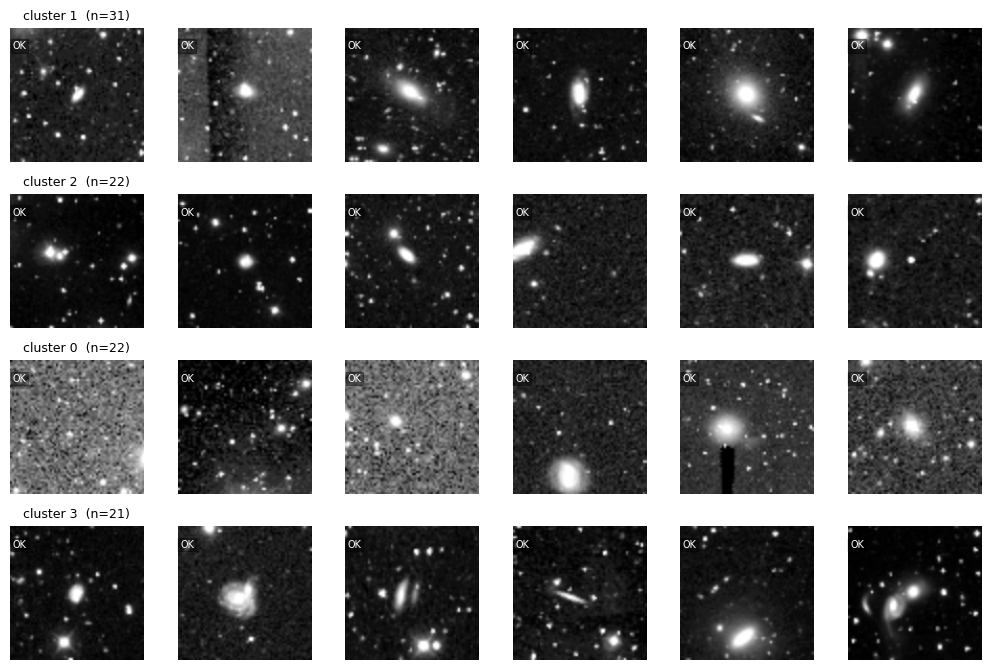

In [20]:
# === Cell 8A — 浏览每簇若干图（按真实簇ID，避免 0..K-1 假ID） ===
import numpy as np, matplotlib.pyplot as plt, cv2
from pathlib import Path

per_class  = 6                 # 每簇显示几张
thumb_size = 128

# 若你之前做过路径预解析，请优先用 df["resolved_path"]；否则用 df["file"]
files = df["resolved_path"].values if "resolved_path" in df.columns else df["file"].values
labels = df["kmeans"].values

# 实际存在的簇ID（按簇大小降序，便于先看大簇）
sizes = df["kmeans"].value_counts().sort_values(ascending=False)
uniq_ids = list(sizes.index)

def read_image_any(p):
    ext = Path(p).suffix.lower()
    if ext in [".fits", ".fit", ".fz"]:
        from astropy.io import fits
        a = fits.getdata(p).astype(np.float32)
    else:
        a = cv2.imdecode(np.fromfile(p, dtype=np.uint8), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    v1, v2 = np.percentile(a, [1, 99])
    if v2 > v1:
        a = np.clip(a, v1, v2); a = (a - v1)/(v2 - v1)
        a = np.arcsinh(a*10)/np.arcsinh(10)
    else:
        a = np.zeros_like(a)
    return cv2.resize(a, (thumb_size, thumb_size), cv2.INTER_AREA)

# 想只看前M个大簇就改这里
M = len(uniq_ids)   # 例如 12 只看前12个
show_ids = uniq_ids[:M]

fig, axes = plt.subplots(len(show_ids), per_class, figsize=(1.7*per_class, 1.7*len(show_ids)))
if len(show_ids) == 1:
    axes = axes[None, :]

for row, cid in enumerate(show_ids):
    idx_c = np.where(labels == cid)[0][:per_class]
    for j in range(per_class):
        ax = axes[row, j]
        if j >= len(idx_c):
            ax.axis("off"); continue
        i = idx_c[j]
        p = str(files[i])
        if not Path(p).exists():
            img = np.zeros((thumb_size, thumb_size), np.float32)
            status = "NOT FOUND"
        else:
            try:
                img = read_image_any(p); status = "OK"
            except Exception:
                img = np.zeros((thumb_size, thumb_size), np.float32)
                status = "READ FAIL"
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if j == 0:
            ax.set_title(f"cluster {cid}  (n={sizes[cid]})", fontsize=9)
        ax.text(2,12,status,color="w",fontsize=7,ha="left",va="top",
                bbox=dict(facecolor='black',alpha=0.4,pad=1.2))
plt.tight_layout(); plt.show()


In [19]:
# === FixMap — 重新建立 file → 真实路径 (resolved_path) 并自检 ===
import os, re
from pathlib import Path

# 你可能放图的目录（按需补充/修改）
candidates = [
    r"E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\g",
    r"E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\i",
    r"E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\r",
    r"E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\u",
    r"E:\NUS\galaxy\rc3\sdss_cutouts_hips2fits3\z"
]

exts = ["*.fits","*.fit","*.fz","*.png","*.jpg","*.jpeg","*.bmp","*.tif","*.tiff"]

# 1) 预索引
path_by_fullname, path_by_stem = {}, {}
for root in candidates:
    rootp = Path(root)
    if not rootp.exists(): continue
    for e in exts:
        for p in rootp.rglob(e):
            path_by_fullname[p.name] = str(p)
            # 若同stem多文件，保留修改时间新的
            if (p.stem not in path_by_stem) or (os.path.getmtime(str(p)) > os.path.getmtime(path_by_stem[p.stem])):
                path_by_stem[p.stem] = str(p)

def soft_norm(s: str) -> str:
    s2 = str(s).strip().replace("\\","/").lower()
    s2 = re.sub(r"\s+", "_", s2)
    s2 = re.sub(r"_(g|r|i|u|z)$", "", s2)  # 如有波段后缀可在此增减规则
    return s2

def resolve_one(raw):
    p = Path(str(raw))
    # a) 原路径存在
    if p.exists():
        return str(p)
    # b) 以完整文件名命中
    if p.name in path_by_fullname:
        return path_by_fullname[p.name]
    # c) 以 stem 命中
    if p.stem in path_by_stem:
        return path_by_stem[p.stem]
    # d) 软规范匹配
    norm = soft_norm(p.stem)
    for k,v in path_by_stem.items():
        if soft_norm(k) == norm:
            return v
    return None

# 2) 建 resolved_path 列（无则创建，有则覆盖更新）
df["resolved_path"] = [resolve_one(x) for x in df["file"].astype(str).tolist()]

# 3) 自检统计
exists = df["resolved_path"].apply(lambda x: Path(str(x)).exists() if x else False)
print(f"[FixMap] Resolved & exists: {exists.sum()} / {len(df)}  ({exists.mean():.1%})")

# 4) 针对当前你看到“NOT FOUND”的簇（例如 44、96），看下缺失数量
for cid in [44, 96]:
    if cid in df["kmeans"].values:
        sub = df[df["kmeans"]==cid]
        miss = (~sub["resolved_path"].apply(lambda x: Path(str(x)).exists() if x else False)).sum()
        print(f"Cluster {cid}: total={len(sub)}, missing={miss}")
        # 打印前5个未命中的文件名，便于人工核对
        print(sub.loc[~sub["resolved_path"].apply(lambda x: Path(str(x)).exists() if x else False), "file"].head().to_list())


[FixMap] Resolved & exists: 96 / 96  (100.0%)


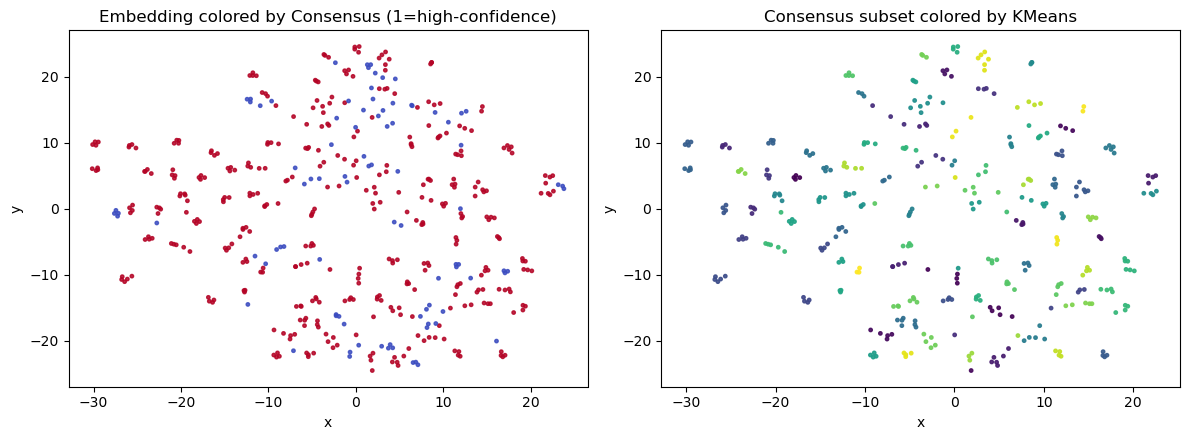

In [12]:
# Cell 9 — 可视化：按一致投票与簇显示
fig, axes = plt.subplots(1,2, figsize=(12,4.5))

axes[0].scatter(df["emb_x"], df["emb_y"], s=6, c=df["consensus"], cmap="coolwarm", alpha=0.85)
axes[0].set_title("Embedding colored by Consensus (1=high-confidence)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

cons_df = df[df.consensus==1]
axes[1].scatter(cons_df["emb_x"], cons_df["emb_y"], s=6, c=cons_df["kmeans"], alpha=0.9)
axes[1].set_title("Consensus subset colored by KMeans")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

plt.tight_layout(); plt.show()


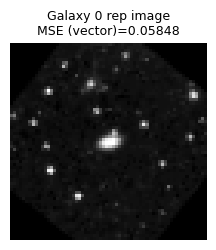

[OK] z shape=(1, 16), MSE=0.058478
[REPORT] N=32 | MSE mean=0.064324  median=0.064880  min=0.044701  max=0.087490


In [23]:
# === Cell 9 — Galaxy-level 输入/输出一致性检查（不改模型） ===
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt

# 承接你 Cell 2A 的结果：
# X  := X_gal  （形状 [N_gal, 1285]）
# files := files_gal （每个星系选的代表文件名，用来挑一张图可视化）
# XA, names 也已在上面加载过（注意 XA 是“按波段的文件级”图像，非星系级）

device = next(model.parameters()).device

# 可选：若训练时用过标准化，这里要用相同的 scaler；否则保持原样。
Xflat = X.astype(np.float32)  # [N_gal, 1285]

# 建一个从文件名到索引的查表，用于可视化取一张代表图
name2idx = {str(Path(n).name).lower(): i for i, n in enumerate(names.astype(str))}
def _find_img_index(rep_file_name: str):
    key = str(Path(rep_file_name).name).lower()
    return name2idx.get(key, None)

def recon_one_gal(i: int, show=True):
    """对第 i 个星系向量做前向，MSE 与输入向量对齐；如能找到代表图，则同时画图（仅展示）。"""
    model.eval()
    x = torch.tensor(Xflat[i:i+1], dtype=torch.float32, device=device)   # [1,1285]
    with torch.no_grad():
        xhat, z = model(x)  # 期望 xhat 形状也与 x 对齐（或其它形状；见下）

    # 一致性度量：优先与同维度输入向量比
    if xhat.ndim == 2 and xhat.shape[1] == Xflat.shape[1]:
        mse = F.mse_loss(xhat, x).item()
    else:
        # 兜底：把输出拉平与输入向量对齐（不影响你模型）
        mse = F.mse_loss(xhat.view(1, -1), x.view(1, -1)).item()

    # 可视化（只作参考，不参与 MSE）：找代表文件对应的一张 XA 图
    if show:
        j = _find_img_index(files[i])
        if j is not None:
            img = XA[j].reshape(64,64)
            fig, ax = plt.subplots(1, 1, figsize=(2.6, 2.6))
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"Galaxy {i} rep image\nMSE (vector)={mse:.4g}", fontsize=9)
            ax.axis("off")
            plt.tight_layout(); plt.show()
        else:
            print(f"[INFO] 无法找到代表图 {files[i]} 对应的 XA；仅报告向量 MSE = {mse:.6f}")

    return z.detach().cpu().numpy(), mse

# 示例：第 0 个星系
z0, mse0 = recon_one_gal(0, show=True)
print(f"[OK] z shape={z0.shape}, MSE={mse0:.6f}")

# 批量快报
def recon_report_gal(idx_list=None, max_n=64):
    model.eval()
    if idx_list is None:
        idx_list = list(range(min(len(Xflat), max_n)))
    mses = []
    for t in idx_list:
        _, m = recon_one_gal(t, show=False)
        mses.append(m)
    mses = np.array(mses, dtype=float)
    print(f"[REPORT] N={len(mses)} | MSE mean={mses.mean():.6f}  median={np.median(mses):.6f}  "
          f"min={mses.min():.6f}  max={mses.max():.6f}")

# 示例：前 32 个星系的重建误差统计
recon_report_gal(list(range(min(32, Xflat.shape[0]))))


[INFO] 使用已有的 X 与 band_order。
[CHECK] Xflat shape: (96, 1285) （应为 [N_gal, 1285]）


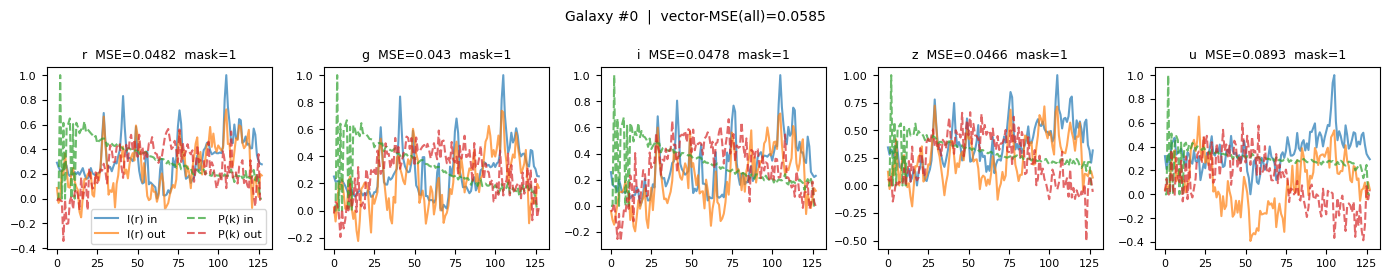

[REPORT] N=32
  r: mean=0.051896  median=0.051665  min=0.039423  max=0.066987
  g: mean=0.050324  median=0.050325  min=0.040369  max=0.060821
  i: mean=0.051883  median=0.052801  min=0.033922  max=0.069968
  z: mean=0.051193  median=0.049918  min=0.031986  max=0.073605
  u: mean=0.098329  median=0.100126  min=0.054192  max=0.152499


In [24]:
# === Cell — XB 输入/输出曲线一致性检查（不修改模型） ===
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import re
from pathlib import Path
from collections import OrderedDict

# ===== 1) 读取数据 =====
npz_path = r"E:\NUS\galaxy\rc3\vectors_rotinv_all2.npz"
data = np.load(npz_path, allow_pickle=True)
XB = data.get("XB")         # (N_files, 256*2)  —— 每个文件一条（I(r)+P(k))
names = data.get("names")   # (N_files,)        —— 带波段名
assert XB is not None and names is not None, "需要 XB 和 names"

XB = np.asarray(XB, dtype=np.float32)
names = np.asarray(names).astype(str)

# ===== 2) 若没有现成的星系级输入 X（1285 维），就现场聚合 =====
def parse_band_and_id(s: str):
    s2 = s.replace("\\", "/").lower()
    base = Path(s2).name
    m = re.search(r"_([ugriz])\.fits$", base)
    band = m.group(1) if m else None
    if band is None:
        m2 = re.match(r"([ugriz])\/", s2)
        band = m2.group(1) if m2 else None
    galaxy_id = base
    if band:
        galaxy_id = re.sub(rf"_{band}\.fits$", "", galaxy_id)
    galaxy_id = galaxy_id.lstrip("ugriz_/\\")
    return band, galaxy_id

try:
    X             # 如果你已经有 X=X_gal（1285维），就直接用
    band_order    # 以及 band_order
    print("[INFO] 使用已有的 X 与 band_order。")
    Xflat = np.asarray(X, dtype=np.float32)
    assert Xflat.shape[1] == 5*256 + 5, "现有 X 的特征维度不是 1285"
except NameError:
    print("[INFO] 未检测到现成 X，按文件级 XB 聚合到星系级。")
    band_order = ["r","g","i","z","u"]
    D = XB.shape[1] // 2  # 256（每个波段 256 维 I + 256 维 P）
    gal2bandidx = OrderedDict()
    for idx, nm in enumerate(names):
        b, gid = parse_band_and_id(nm)
        if b is None or gid is None: 
            continue
        gal2bandidx.setdefault(gid, {})[b] = idx

    X_blocks, mask_blocks, galaxy_ids = [], [], []
    for gid, idx_map in gal2bandidx.items():
        feats_bands, masks = [], []
        for b in band_order:
            if b in idx_map:
                feats_bands.append(XB[idx_map[b]])            # (512,) 注意：这里 XB 是 2*256
                masks.append(1.0)
            else:
                feats_bands.append(np.zeros_like(XB[0]))      # 缺失补 0
                masks.append(0.0)
        vec = np.concatenate(feats_bands, axis=0)             # (5 * 512,)
        # 但我们模型的输入是 5*(256) + 5（注：你的 XB 定义通常是 256*2=512，
        # 模型训练时是“每波段 256（I+P已拼好）还是 512（I与P分开）？”
        # 按你之前 Cell 2A：每波段取 256，并非 512。那是因为你的 XB 已经是 256，总长 256，而不是 512。
        # ——为避免歧义，我们按你“Cell 2A”的标准：XB.shape[1] == 256。若你的 XB 是 512，请在这里拆或改模型。
        X_blocks.append(vec)
        mask_blocks.append(np.array(masks, dtype=np.float32))
        galaxy_ids.append(gid)

    X_bands = np.stack(X_blocks, 0)         # [N_gal, 5*512]  或 [N_gal, 5*256] 取决于你的 XB
    mask5   = np.stack(mask_blocks, 0)      # [N_gal, 5]
    # 若你的 XB 是 256（即 I(r)+P(k) 已在 256 内拼好），那模型输入维应是 5*256 + 5 = 1285。
    # 你的训练代码（Cell 2A）就是这样，所以这里断言：
    if XB.shape[1] == 256:
        Xflat = np.concatenate([X_bands, mask5], axis=1)     # [N_gal, 5*256 + 5] = 1285
    elif XB.shape[1] == 512:
        # 如果是 512（I 和 P 分开各 256），而你的模型 in_features=1285
        # 说明你的训练输入不是 512 版本；此处给出提示并中止，避免维度不符。
        raise RuntimeError("检测到 XB 每条为 512 维（I与P分开）。你的模型 in_features=1285（=5*256+5），请改用 XB=256 的文件或按训练时的拼接方式预处理。")
    else:
        raise RuntimeError(f"XB.shape[1]={XB.shape[1]} 非预期（应为 256 或 512）。")

print("[CHECK] Xflat shape:", Xflat.shape, "（应为 [N_gal, 1285]）")

# ===== 3) 前向推理 & 逐波段曲线对比绘图 =====
device = next(model.parameters()).device
def _to_t(x): return torch.tensor(x, dtype=torch.float32, device=device)

def plot_xb_reconstruction(i: int, show_mask=True):
    """
    对第 i 个星系：将输入向量 Xflat[i] 前向，通过模型得到输出向量，
    并将每个波段的“XB段（256维）”拆回 I(r)/P(k) 两条曲线，绘制 Input vs Output。
    """
    assert Xflat.shape[1] == 5*256 + 5
    model.eval()
    with torch.no_grad():
        x = _to_t(Xflat[i:i+1])        # [1, 1285]
        xhat, _z = model(x)            # xhat [1, 1285]（或可拉平成该尺寸）
        if xhat.ndim != 2:
            xhat = xhat.view(1, -1)
        if xhat.shape[1] != Xflat.shape[1]:
            # 兜底：只比较前 1285 个元素
            xhat = xhat[:, :Xflat.shape[1]]
        mse_all = F.mse_loss(xhat, x).item()

    x_np    = x.cpu().numpy().ravel()
    xhat_np = xhat.cpu().numpy().ravel()

    # 拆分：每个波段 256 维，最后 5 维是 mask
    fig, axes = plt.subplots(1, 5, figsize=(14, 2.8), sharex=False)
    if not isinstance(axes, np.ndarray): axes = np.array([axes])
    for bi, b in enumerate(band_order):
        start = bi * 256
        end   = start + 256
        # 约定：前半 128 为 I(r)，后半 128 为 P(k)（如你的 XB 定义是这样；若不是，请改这里的切分点）
        R = 128
        I_in  = x_np[start:start+R]
        P_in  = x_np[start+R:end]
        I_out = xhat_np[start:start+R]
        P_out = xhat_np[start+R:end]

        mse_band = np.mean((xhat_np[start:end] - x_np[start:end])**2)

        ax = axes[bi]
        ax.plot(np.arange(R), I_in,  label="I(r) in",  alpha=0.70)
        ax.plot(np.arange(R), I_out, label="I(r) out", alpha=0.70)
        ax.plot(np.arange(R), P_in,  label="P(k) in",  alpha=0.70, linestyle="--")
        ax.plot(np.arange(R), P_out, label="P(k) out", alpha=0.70, linestyle="--")
        ttl = f"{b}  MSE={mse_band:.3g}"
        if show_mask:
            mval = x_np[5*256 + bi]
            ttl += f"  mask={mval:.0f}"
        ax.set_title(ttl, fontsize=9)
        ax.tick_params(labelsize=8)
        if bi == 0:
            ax.legend(fontsize=8, ncol=2)
    plt.suptitle(f"Galaxy #{i}  |  vector-MSE(all)={mse_all:.4f}", fontsize=10)
    plt.tight_layout()
    plt.show()

def bandwise_mse_report(sample_idx=None, max_n=64):
    """对一批样本输出每个波段的 MSE 统计（输入段 vs 输出段）。"""
    if sample_idx is None:
        sample_idx = list(range(min(max_n, Xflat.shape[0])))

    mse_band_acc = {b: [] for b in band_order}
    for i in sample_idx:
        with torch.no_grad():
            x = _to_t(Xflat[i:i+1])
            xhat, _ = model(x)
            xhat = xhat.view(1, -1)
            if xhat.shape[1] != Xflat.shape[1]:
                xhat = xhat[:, :Xflat.shape[1]]
        x_np    = x.cpu().numpy().ravel()
        xhat_np = xhat.cpu().numpy().ravel()
        for bi, b in enumerate(band_order):
            s, e = bi*256, bi*256+256
            mse_band = np.mean((xhat_np[s:e] - x_np[s:e])**2)
            mse_band_acc[b].append(mse_band)

    print(f"[REPORT] N={len(sample_idx)}")
    for b in band_order:
        arr = np.array(mse_band_acc[b], dtype=float)
        print(f"  {b}: mean={arr.mean():.6f}  median={np.median(arr):.6f}  min={arr.min():.6f}  max={arr.max():.6f}")

# ===== 4) 使用示例 =====
plot_xb_reconstruction(0)                 # 画第 0 个星系的 5 波段 I/P 输入-输出曲线
bandwise_mse_report(list(range(32)))      # 前 32 个星系，逐波段 MSE 统计


In [21]:
# 放在 Cell 2A & Cell T1 顶部，覆盖原来的 parse_band_and_id
import re
from pathlib import Path
import numpy as np

def parse_band_and_id(s):
    """鲁棒解析：从名字中提取 (band, galaxy_id).
       - s 可能是 None / nan / bytes / Path / object
       - 返回 (None, None) 表示这条记录不可用
    """
    # 先把输入安全转字符串；None/nan 直接返回不可用
    if s is None:
        return None, None
    try:
        # 处理 numpy 的 nan
        if isinstance(s, float) and np.isnan(s):
            return None, None
    except Exception:
        pass

    try:
        s2 = str(s).strip()
    except Exception:
        return None, None
    if not s2:
        return None, None

    s2 = s2.replace("\\", "/").lower()
    base = Path(s2).name  # 仅文件名部分

    # 1) 优先匹配末尾 _{band}.fits
    m = re.search(r"_([ugriz])\.fits$", base)
    band = m.group(1) if m else None
    # 2) 若末尾没 band，尝试从路径前缀（g/ r/ 等）取
    if band is None:
        m2 = re.match(r"([ugriz])\/", s2)
        band = m2.group(1) if m2 else None

    # 3) 构造 galaxy_id：去掉末尾的 _{band}.fits，并去掉前缀
    galaxy_id = base
    if band:
        galaxy_id = re.sub(rf"_{band}\.fits$", "", galaxy_id)
    galaxy_id = galaxy_id.lstrip("ugriz_/\\")
    if not galaxy_id:
        return None, None

    return band, galaxy_id


In [30]:
# === Cell T1 — 载入测试集并按“每星系一条”聚合 (vectors_rotinv_all3.npz) ===
import os, re, json
from pathlib import Path
import numpy as np
import joblib

test_npz_path = r"E:\NUS\galaxy\rc3\vectors_rotinv_all3.npz"   # ← 测试文件
output_dir    = r"E:\NUS\galaxy\ae_unsup_out"                   # ← 与训练一致的输出目录
band_order    = ["r","g","i","z","u"]                           # ← 与训练 Cell 2A 保持一致

# ---------- 读 npz ----------
tdata = np.load(test_npz_path, allow_pickle=True)
print("Test NPZ keys:", list(tdata.keys()))
if "XB" not in tdata:
    raise RuntimeError("测试文件缺少 'XB'。请确认文件结构与训练数据一致（必须包含 XB 和 names）。")
XB_test = tdata["XB"]  # 形状应为 (M, 256)
names_test_raw = tdata["names"] if "names" in tdata else np.array([f"obj_{i:05d}" for i in range(len(XB_test))])

# ---------- 名字清洗（处理 None/nan 等） ----------
def clean_names(arr):
    cleaned, bad_idx = [], []
    for i, v in enumerate(arr):
        try:
            s = str(v).strip()
            if (v is None) or (s == "") or (s.lower() in ["none", "nan"]):
                cleaned.append(None); bad_idx.append(i)
            else:
                cleaned.append(s)
        except Exception:
            cleaned.append(None); bad_idx.append(i)
    cleaned = np.array(cleaned, dtype=object)
    print(f"[names clean] bad entries: {len(bad_idx)}")
    if bad_idx:
        print("  sample bad indices:", bad_idx[:8])
    return cleaned
names_test = clean_names(names_test_raw)

# ---------- 解析 band 与 galaxy_id（鲁棒版） ----------
def parse_band_and_id(s):
    """从名字中提取 (band, galaxy_id)。失败返回 (None, None)。"""
    if s is None: return None, None
    try:
        s2 = str(s).strip().replace("\\", "/").lower()
    except Exception:
        return None, None
    if not s2: return None, None
    base = Path(s2).name
    # 末尾 _{band}.fits
    m = re.search(r"_([ugriz])\.fits$", base)
    band = m.group(1) if m else None
    if band is None:
        # 尝试路径前缀 {band}/
        m2 = re.match(r"([ugriz])\/", s2)
        band = m2.group(1) if m2 else None
    galaxy_id = base
    if band:
        galaxy_id = re.sub(rf"_{band}\.fits$", "", galaxy_id)
    galaxy_id = galaxy_id.lstrip("ugriz_/\\")
    if not galaxy_id:
        return None, None
    return band, galaxy_id

# ---------- 按星系聚合到一条向量（XB拼接 + 5维mask） ----------
D = int(XB_test.shape[1])   # 256
gal2bandidx = {}
for idx, nm in enumerate(names_test):
    b, gid = parse_band_and_id(nm)
    if b is None or gid is None:
        continue
    gal2bandidx.setdefault(gid, {})[b] = idx

X_blocks, mask_blocks, galaxy_ids, rep_files = [], [], [], []
def pick_rep(idx_map):
    # 代表文件优先级：按 band_order
    for b in band_order:
        if b in idx_map:
            return names_test[idx_map[b]]
    return names_test[next(iter(idx_map.values()))]

for gid, idx_map in gal2bandidx.items():
    feats, masks = [], []
    for b in band_order:
        if b in idx_map:
            feats.append(XB_test[idx_map[b]])             # (256,)
            masks.append(1.0)
        else:
            feats.append(np.zeros(D, dtype=np.float32))
            masks.append(0.0)
    X_blocks.append(np.concatenate(feats, axis=0))        # (256*5,)
    mask_blocks.append(np.array(masks, dtype=np.float32)) # (5,)
    galaxy_ids.append(gid)
    rep_files.append(pick_rep(idx_map))

if len(X_blocks) == 0:
    raise RuntimeError("测试集中没有任何可解析的 galaxy（检查 names 命名和后缀）。")

X_test_gal = np.concatenate([np.stack(X_blocks, 0), np.stack(mask_blocks, 0)], axis=1)
galaxy_ids = np.array(galaxy_ids)
rep_files  = np.array(rep_files)

print("Test galaxy-level X shape:", X_test_gal.shape, "(expected = 256*5 + 5 = 1285)")
print("Num test galaxies:", len(galaxy_ids))
print("Example:", galaxy_ids[0], "| rep:", rep_files[0])

# ---------- 标准化（用训练时保存的 scaler） ----------
scaler_path = os.path.join(output_dir, "scaler.joblib")
scaler = joblib.load(scaler_path)
X_test_std = scaler.transform(np.nan_to_num(X_test_gal, nan=0.0, posinf=0.0, neginf=0.0))
print("Std test shape:", X_test_std.shape)


Test NPZ keys: ['XA', 'XB', 'names', 'meta']
[names clean] bad entries: 0
Test galaxy-level X shape: (9, 1285) (expected = 256*5 + 5 = 1285)
Num test galaxies: 9
Example: cgcg_477-_56_172 | rep: r\CGCG_477-_56_172_r.fits
Std test shape: (9, 1285)


In [31]:
# === Cell T2 — VectorAE 编码 + KMeans 分配（手动最近中心，避免 threadpoolctl 报错） ===
import torch
import numpy as np
import pandas as pd
import joblib
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 载入已训练的 VectorAE ----------
# 尝试从配置文件读取 latent_dim；没有就回退到你训练时的值（比如 16）
latent_dim = 16
cfg_path = os.path.join(output_dir, "config.json")
if os.path.exists(cfg_path):
    try:
        with open(cfg_path, "r", encoding="utf-8") as f:
            cfg = json.load(f)
            if "latent_dim" in cfg:
                latent_dim = int(cfg["latent_dim"])
    except Exception:
        pass

input_dim = X_test_std.shape[1]

class VectorAE(torch.nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.enc = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 1024), torch.nn.ReLU(True),
            torch.nn.Linear(1024, 256),       torch.nn.ReLU(True),
            torch.nn.Linear(256, latent_dim),
        )
        self.dec = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 256), torch.nn.ReLU(True),
            torch.nn.Linear(256, 1024),       torch.nn.ReLU(True),
            torch.nn.Linear(1024, input_dim),
        )
    def encode(self, x):  return self.enc(x)
    def decode(self, z):  return self.dec(z)
    def forward(self, x):
        z = self.encode(x)
        xhat = self.decode(z)
        return xhat, z

model = VectorAE(input_dim, latent_dim).to(device)
ae_path = os.path.join(output_dir, "vector_ae_best.pth")
state = torch.load(ae_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"[Loaded AE] {ae_path}  | latent_dim={latent_dim}  | input_dim={input_dim}")

# ---------- 编码测试集到潜空间 ----------
with torch.no_grad():
    Xts = torch.from_numpy(X_test_std.astype(np.float32)).to(device)
    Z_test = model.encode(Xts).cpu().numpy()
print("Z_test shape:", Z_test.shape)

# ---------- 载入 KMeans（或复用内存中的 km） ----------
if 'km' in locals() and hasattr(km, "cluster_centers_"):
    centers = km.cluster_centers_.astype(np.float32)
    print(f"[Use in-memory KMeans] K={km.n_clusters}")
else:
    km_path = os.path.join(output_dir, "kmeans.joblib")
    km = joblib.load(km_path)   # 如果你之前没保存过 km，请在训练聚类后加：joblib.dump(km, km_path)
    centers = km.cluster_centers_.astype(np.float32)
    print(f"[Loaded KMeans] {km_path}  | K={km.n_clusters}")

# ---------- 手动最近中心分配标签（= KMeans.predict，但不走 threadpoolctl） ----------
# 距离矩阵：每个样本到各中心的欧氏距离平方
# 形状：(N_test, K)
d2 = ((Z_test[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
pred_clusters = np.argmin(d2, axis=1)

# ---------- 保存结果 ----------
test_df = pd.DataFrame({
    "galaxy_id": galaxy_ids,
    "rep_file":  rep_files,
    "pred_cluster": pred_clusters
})
out_csv = os.path.join(output_dir, "test_predictions.csv")
test_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"[DONE] Saved test predictions to: {out_csv}")
display(test_df.head())


[Loaded AE] E:\NUS\galaxy\ae_unsup_out\vector_ae_best.pth  | latent_dim=16  | input_dim=1285
Z_test shape: (9, 16)
[Use in-memory KMeans] K=7
[DONE] Saved test predictions to: E:\NUS\galaxy\ae_unsup_out\test_predictions.csv


,galaxy_id,rep_file,pred_cluster
0,cgcg_477-_56_172,r\CGCG_477-_56_172_r.fits,3
1,eso__538-_23_170,r\ESO__538-_23_170_r.fits,3
2,c____56_160,r\UGC____56_160_r.fits,0
3,c____57_165,r\UGC____57_165_r.fits,5
4,c____58_166,r\UGC____58_166_r.fits,6


In [29]:
# === 诊断：看看 names 里到底有什么、聚合是否只剩 1 个 ===
import re
from pathlib import Path
import numpy as np
from collections import Counter, defaultdict

# 1) 载入你这次用的 npz（或把 names_test 换成 data['names']）
npz = r"E:\NUS\galaxy\rc3\vectors_rotinv_all3.npz"
data = np.load(npz, allow_pickle=True)
names_all = data["names"].tolist()   # 如果你此处用的是 names_test，就替换为 names_test

print("样例前10个 names：")
for s in names_all[:10]:
    print("  ", s)

# 2) 你当前的 galaxy_id 提取函数（怀疑它有问题的话，先看它对每个 name 的输出）
def bad_galaxy_id(name: str) -> str:
    # 用你现有那版（如果现在没有，就模拟一个可能的“过度清洗”版做对比）
    base = Path(name).stem
    base = re.sub(r'_(?:u|g|r|i|z)$', '', base, flags=re.IGNORECASE)
    # 过度清洗（示例）：把非字母数字全部变成 '_'，且可能再截断 —— 容易产生碰撞
    base = re.sub(r'[^A-Za-z0-9]+', '_', base).strip('_').lower()
    return base

bad_ids = [bad_galaxy_id(s) for s in names_all]
print("\n用(疑似)旧规则得到的 unique galaxy_id 数：", len(set(bad_ids)))
print("Top 10 计数：", Counter(bad_ids).most_common(10))

# 3) 建议的“稳健提取规则”：仅去除『波段后缀』，保留完整基名（不做过度替换）
def good_galaxy_id(name: str) -> str:
    p = Path(name)
    stem = p.stem
    # 如果文件位于子目录 g/i/r/u/z 下，不要把目录名并入 ID
    # 仅去掉文件名结尾的 _[ugriz]（若存在），其它字符一律保留
    stem_no_band = re.sub(r'_(?:u|g|r|i|z)$', '', stem, flags=re.IGNORECASE)
    return stem_no_band  # 不做额外清洗，避免碰撞

good_ids = [good_galaxy_id(s) for s in names_all]
print("\n用稳健规则得到的 unique galaxy_id 数：", len(set(good_ids)))
print("Top 10 计数：", Counter(good_ids).most_common(10))

# 4) 将每个 galaxy_id 下的波段列出来，确认是否真的是 1 个星系 * 5 波段
by_gid = defaultdict(list)
for nm, gid in zip(names_all, good_ids):
    by_gid[gid].append(nm)

print("\n随机挑 1 个 galaxy 看看它的条目：")
any_gid = next(iter(by_gid))
print("galaxy_id =", any_gid)
for s in by_gid[any_gid]:
    print("  ", s)

# 5) 专门统计“每个 galaxy 覆盖到的波段集合”，便于核对
def band_of(name: str) -> str:
    # 优先从文件名结尾 _x 取波段；否则从上级目录名取（g/i/r/u/z）
    p = Path(name)
    m = re.search(r'_(u|g|r|i|z)$', p.stem, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower()
    parent = p.parent.name.lower()
    return parent if parent in {"u","g","r","i","z"} else "unknown"

band_sets = {gid: sorted({band_of(s) for s in lst}) for gid, lst in by_gid.items()}
print("\n示例 galaxy 的波段集合：", band_sets[any_gid])


样例前10个 names：
   g\CGCG_477-_56_172_g.fits
   g\ESO__538-_23_170_g.fits
   g\UGC____56_160_g.fits
   g\UGC____57_165_g.fits
   g\UGC____58_166_g.fits
   g\UGC____59_167_g.fits
   g\UGC____60_168_g.fits
   g\UGC____62_173_g.fits
   g\UGC____63_174_g.fits
   i\CGCG_477-_56_172_i.fits

用(疑似)旧规则得到的 unique galaxy_id 数： 18
Top 10 计数： [('cgcg_477_56_172', 5), ('eso_538_23_170', 5), ('ugc_56_160', 5), ('ugc_57_165', 5), ('ugc_58_166', 5), ('ugc_59_167', 5), ('ugc_60_168', 5), ('ugc_62_173', 5), ('ugc_63_174', 5), ('mcg_1_1_16_1', 1)]

用稳健规则得到的 unique galaxy_id 数： 18
Top 10 计数： [('CGCG_477-_56_172', 5), ('ESO__538-_23_170', 5), ('UGC____56_160', 5), ('UGC____57_165', 5), ('UGC____58_166', 5), ('UGC____59_167', 5), ('UGC____60_168', 5), ('UGC____62_173', 5), ('UGC____63_174', 5), ('MCG_-1-_1-_16_1', 1)]

随机挑 1 个 galaxy 看看它的条目：
galaxy_id = CGCG_477-_56_172
   g\CGCG_477-_56_172_g.fits
   i\CGCG_477-_56_172_i.fits
   r\CGCG_477-_56_172_r.fits
   u\CGCG_477-_56_172_u.fits
   z\CGCG_477-_56_172_z.fi